# Make the new gif

In this notebook we make the new gif using the model trained on the Snellius cluster using a CelebA dataset with a large amount of Julia Roberts images added to it. 

# Loading the model architecture

Here load the model architecture to which the extracted weights are attached

In [3]:


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as Datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import torchvision.models as models
import torchvision.utils as vutils
from torch.hub import load_state_dict_from_url

import os
import random
import numpy as np
import math
from IPython.display import clear_output
import matplotlib.pyplot as plt
from PIL import Image






import torch
import torch.nn as nn
import torch.utils.data


class ResDown(nn.Module):
    """
    Residual down sampling block for the encoder
    """

    def __init__(self, channel_in, channel_out, kernel_size=3):
        super(ResDown, self).__init__()
        self.conv1 = nn.Conv2d(channel_in, channel_out // 2, kernel_size, 2, kernel_size // 2)
        self.bn1 = nn.BatchNorm2d(channel_out // 2, eps=1e-4)
        self.conv2 = nn.Conv2d(channel_out // 2, channel_out, kernel_size, 1, kernel_size // 2)
        self.bn2 = nn.BatchNorm2d(channel_out, eps=1e-4)

        self.conv3 = nn.Conv2d(channel_in, channel_out, kernel_size, 2, kernel_size // 2)

        self.act_fnc = nn.ELU()

    def forward(self, x):
        skip = self.conv3(x)
        x = self.act_fnc(self.bn1(self.conv1(x)))
        x = self.conv2(x)
        return self.act_fnc(self.bn2(x + skip))


class ResUp(nn.Module):
    """
    Residual up sampling block for the decoder
    """

    def __init__(self, channel_in, channel_out, kernel_size=3, scale_factor=2):
        super(ResUp, self).__init__()

        self.conv1 = nn.Conv2d(channel_in, channel_in // 2, kernel_size, 1, kernel_size // 2)
        self.bn1 = nn.BatchNorm2d(channel_in // 2, eps=1e-4)
        self.conv2 = nn.Conv2d(channel_in // 2, channel_out, kernel_size, 1, kernel_size // 2)
        self.bn2 = nn.BatchNorm2d(channel_out, eps=1e-4)

        self.conv3 = nn.Conv2d(channel_in, channel_out, kernel_size, 1, kernel_size // 2)

        self.up_nn = nn.Upsample(scale_factor=scale_factor, mode="nearest")

        self.act_fnc = nn.ELU()

    def forward(self, x):
        x = self.up_nn(x)
        skip = self.conv3(x)
        x = self.act_fnc(self.bn1(self.conv1(x)))
        x = self.conv2(x)

        return self.act_fnc(self.bn2(x + skip))


class Encoder(nn.Module):
    """
    Encoder block
    Built for a 3x64x64 image and will result in a latent vector of size z x 1 x 1
    As the network is fully convolutional it will work for images LARGER than 64
    For images sized 64 * n where n is a power of 2, (1, 2, 4, 8 etc) the latent feature map size will be z x n x n

    When in .eval() the Encoder will not sample from the distribution and will instead output mu as the encoding vector
    and log_var will be None
    """
    def __init__(self, channels, ch=64, latent_channels=512):
        super(Encoder, self).__init__()
        self.conv_in = nn.Conv2d(channels, ch, 7, 1, 3)
        self.res_down_block1 = ResDown(ch, 2 * ch)
        self.res_down_block2 = ResDown(2 * ch, 4 * ch)
        self.res_down_block3 = ResDown(4 * ch, 8 * ch)
        self.res_down_block4 = ResDown(8 * ch, 16 * ch)
        self.conv_mu = nn.Conv2d(16 * ch, latent_channels, 4, 1)
        self.conv_log_var = nn.Conv2d(16 * ch, latent_channels, 4, 1)
        self.act_fnc = nn.ELU()

    def sample(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        x = self.act_fnc(self.conv_in(x))
        x = self.res_down_block1(x)  # 32
        x = self.res_down_block2(x)  # 16
        x = self.res_down_block3(x)  # 8
        x = self.res_down_block4(x)  # 4
        mu = self.conv_mu(x)  # 1
        log_var = self.conv_log_var(x)  # 1

        if self.training:
            x = self.sample(mu, log_var)
        else:
            x = mu

        return x, mu, log_var


class Decoder(nn.Module):
    """
    Decoder block
    Built to be a mirror of the encoder block
    """

    def __init__(self, channels, ch=64, latent_channels=512):
        super(Decoder, self).__init__()
        self.conv_t_up = nn.ConvTranspose2d(latent_channels, ch * 16, 4, 1)
        self.res_up_block1 = ResUp(ch * 16, ch * 8)
        self.res_up_block2 = ResUp(ch * 8, ch * 4)
        self.res_up_block3 = ResUp(ch * 4, ch * 2)
        self.res_up_block4 = ResUp(ch * 2, ch)
        self.conv_out = nn.Conv2d(ch, channels, 3, 1, 1)
        self.act_fnc = nn.ELU()

    def forward(self, x):
        x = self.act_fnc(self.conv_t_up(x))  # 4
        x = self.res_up_block1(x)  # 8
        x = self.res_up_block2(x)  # 16
        x = self.res_up_block3(x)  # 32
        x = self.res_up_block4(x)  # 64
        x = torch.tanh(self.conv_out(x))

        return x 


class VAE(nn.Module):
    """
    VAE network, uses the above encoder and decoder blocks
    """
    def __init__(self, channel_in=3, ch=64, latent_channels=512):
        super(VAE, self).__init__()
        """Res VAE Network
        channel_in  = number of channels of the image 
        z = the number of channels of the latent representation
        (for a 64x64 image this is the size of the latent vector)
        """

        self.encoder = Encoder(channel_in, ch=ch, latent_channels=latent_channels)
        self.decoder = Decoder(channel_in, ch=ch, latent_channels=latent_channels)

    def forward(self, x):
        encoding, mu, log_var = self.encoder(x)
        recon_img = self.decoder(encoding)
        return recon_img, mu, log_var


In [6]:
pip install ipywidgets --upgrade


   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 15.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# Extracting the weights from Huggingface

The weights are quite heavy (nu pun intended) so they are stored on hugging face (*https://huggingface.co/rubenlier/VAEcelebrities*) from where they are extracted. We also load the images from the CelebA set here, which need to be added which can be done by downloading them at *https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html*. Note that I took download=False meaning it does not automatically download them if they are not stored. 



Done loading CelebA.


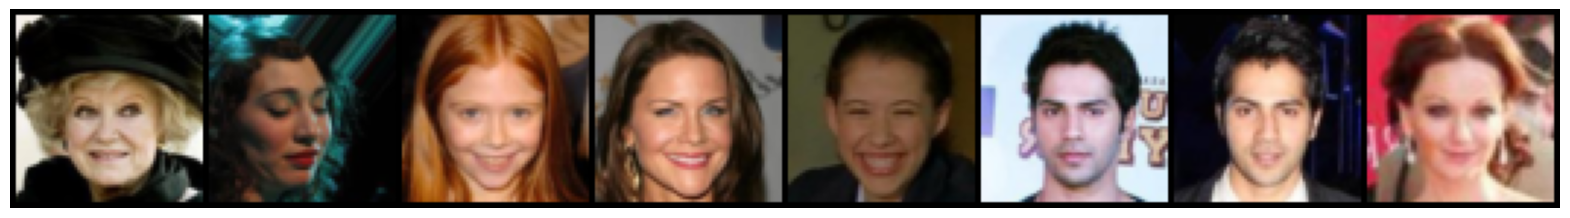

Checkpoint loaded from Hugging Face


In [7]:


import os
import torch
from torchvision import datasets as Datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Parameters
batch_size = 64
image_size = 64
lr = 1e-4
nepoch = 100
start_epoch = 0
model_name = "CelebA"
load_checkpoint = True
save_dir = os.getcwd()
use_cuda = torch.cuda.is_available()
gpu_indx = 0
device = torch.device(f"cuda:{gpu_indx}" if use_cuda else "cpu")

# Download location (will automatically create and extract here)
dataset_root = os.path.join(save_dir, "celeba_data")

# Transform for CelebA
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Download & prepare CelebA
def get_data_celeba(transform, batch_size, download=False, root="celeba_data"):
    print("Downloading (if needed) and loading CelebA...")

    train_dataset = Datasets.CelebA(root=root, split="train", transform=transform, download=download)
    test_dataset  = Datasets.CelebA(root=root, split="test",  transform=transform, download=download)

    trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    testloader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    print("Done loading CelebA.")
    return trainloader, testloader

# Load CelebA
trainloader, testloader = get_data_celeba(transform, batch_size, download=False, root=dataset_root)

# Preview some test images
dataiter = iter(testloader)
test_images, _ = next(dataiter)

plt.figure(figsize=(20, 10))
out = vutils.make_grid(test_images[:8], normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))
plt.axis("off")
plt.show()




#Create VAE network
vae_net = VAE(channel_in=3, ch=64, latent_channels=512).to(device)
# setup optimizer
optimizer = optim.Adam(vae_net.parameters(), lr=lr, betas=(0.5, 0.999))
# #Loss function
loss_log = []




# #Create the save directory if it does note exist
# if not os.path.isdir(save_dir + "/Models"):
#     os.makedirs(save_dir + "/Models")
# if not os.path.isdir(save_dir + "/Results"):
#     os.makedirs(save_dir + "/Results")



from huggingface_hub import hf_hub_download

if load_checkpoint:
    # Replace with your actual repo and filename on Hugging Face
    hf_repo = "rubenlier/VAESnellius"
    filename = "CelebA_64.pt"  # or whatever you named it when uploading

    # Download the file from Hugging Face (cached locally if already downloaded)
    model_path = hf_hub_download(repo_id=hf_repo, filename=filename)

    # Load the checkpoint
    checkpoint = torch.load(model_path, map_location="cpu")
    print("Checkpoint loaded from Hugging Face")

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    vae_net.load_state_dict(checkpoint['model_state_dict'])
    start_epoch = checkpoint["epoch"]
    loss_log = checkpoint["loss_log"]
else:
    #If checkpoint does exist raise an error to prevent accidental overwriting
    if os.path.isfile(save_dir + "/Models/" + model_name + "_" + str(image_size) + ".pt"):
        raise ValueError("Warning Checkpoint exists")
    else:
        print("Starting from scratch")


# In[ ]:





# In[ ]:







# Checking the reconstruction

Below are some reconstructions of the VAE of the input, you see it works decently well.

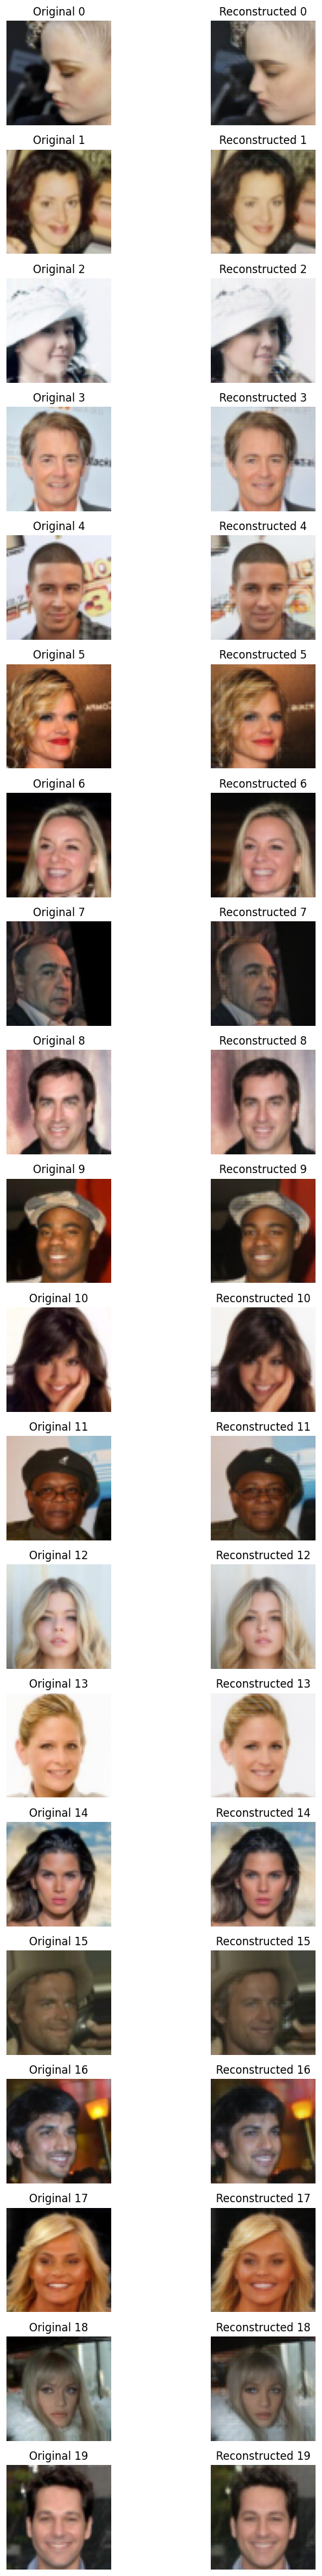

In [8]:
import matplotlib.pyplot as plt

vae_net.eval()
with torch.no_grad():
    test_images, _ = next(iter(testloader))  # get a batch of images
    n = min(20, test_images.size(0))         # make sure batch has at least 20

    plt.figure(figsize=(8, 2 * n))           # one row per image

    for i in range(n):
        x = test_images[40+i:40+i+1].to(device)    # shape: [1, 3, 64, 64]
        recon, _, _ = vae_net(x)

        # Unnormalize
        x_disp = (x.squeeze(0).cpu() + 1) / 2
        recon_disp = (recon.squeeze(0).cpu() + 1) / 2

        # Plot original
        plt.subplot(n, 2, 2 * i + 1)
        plt.imshow(x_disp.permute(1, 2, 0).numpy())
        plt.title(f"Original {i}")
        plt.axis("off")

        # Plot reconstruction
        plt.subplot(n, 2, 2 * i + 2)
        plt.imshow(recon_disp.permute(1, 2, 0).numpy())
        plt.title(f"Reconstructed {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Combining faces

Now we can play around a bit. Let's see what happens if you take 50% of one input and 50% of another. As you can see, this leads to bad results when the faces 
are pointed in different directions.

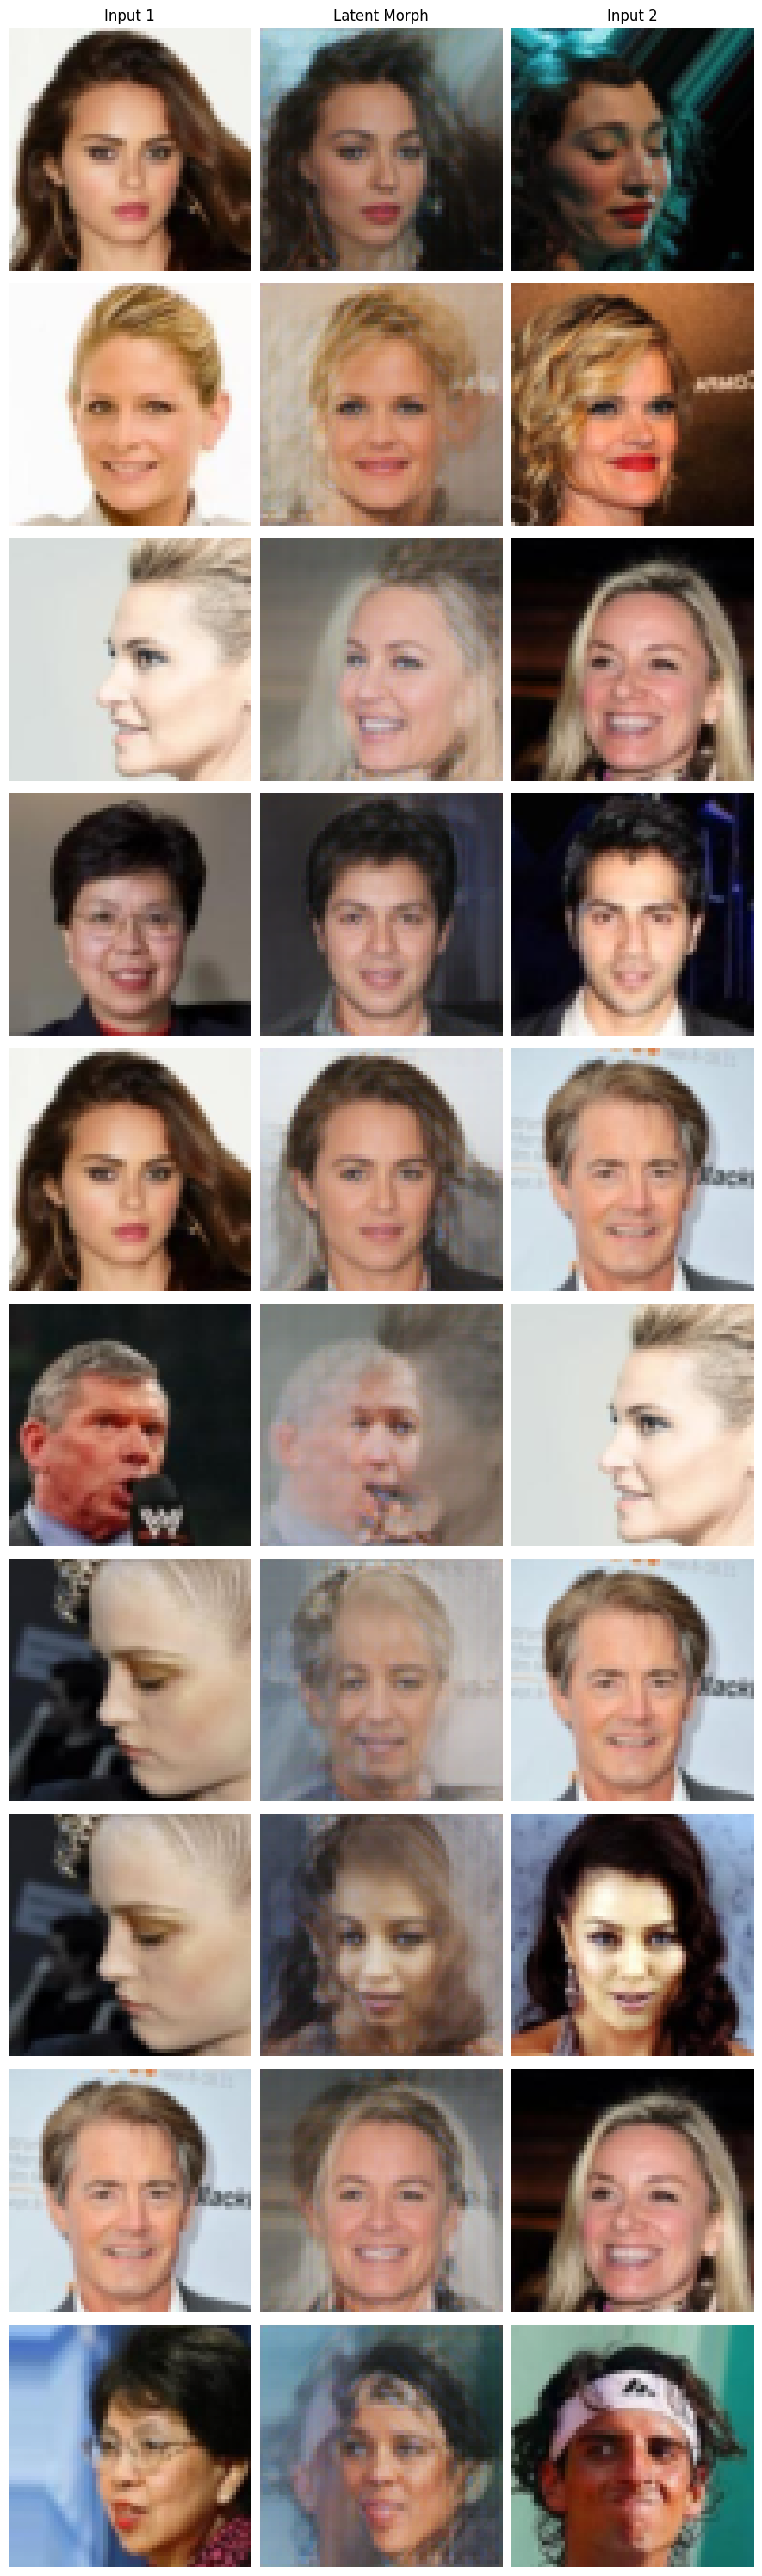

In [9]:
vae_net.eval()

import matplotlib.pyplot as plt

# Get enough test images in one batch
test_images, _ = next(iter(testloader))  # shape: [B, 3, 64, 64]
num_pairs = 10

plt.figure(figsize=(9, 3 * num_pairs))

with torch.no_grad():
    for i in range(num_pairs):
        # Select two random indices from the batch
        idx1, idx2 = torch.randint(0, len(test_images), (2,))
        x1 = test_images[idx1:idx1+1].to(device)
        x2 = test_images[idx2:idx2+1].to(device)

        # Encode
        _, mu1, _ = vae_net.encoder(x1)
        _, mu2, _ = vae_net.encoder(x2)

        # Interpolate in the latent space !!
        mu_avg = 0.5 * mu1 + 0.5 * mu2
        x_interp = vae_net.decoder(mu_avg)

        # Unnormalize
        x1_disp = (x1.squeeze(0).cpu() + 1) / 2
        x2_disp = (x2.squeeze(0).cpu() + 1) / 2
        x_interp_disp = (x_interp.squeeze(0).cpu() + 1) / 2

        # Plot row
        plt.subplot(num_pairs, 3, 3 * i + 1)
        plt.imshow(x1_disp.permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0:
            plt.title("Input 1")

        plt.subplot(num_pairs, 3, 3 * i + 2)
        plt.imshow(x_interp_disp.permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0:
            plt.title("Latent Morph")

        plt.subplot(num_pairs, 3, 3 * i + 3)
        plt.imshow(x2_disp.permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0:
            plt.title("Input 2")

plt.tight_layout()
plt.show()



# Make the morphing gif

Below is code to make a gif that morphs from a single base image into other images as shown in the readme. I chose a particular base for which I thought the image was nicely reconstructed to make the gif look better.


In [10]:
#make the morphing picture


import torch
import imageio
import numpy as np
from torchvision.utils import make_grid

def latent_morph_grid_gif(vae_net, test_images, device, out_path="morph_roster.gif", N=25, frames_per_half=20):
    vae_net.eval()

    with torch.no_grad():
        # Base image → z₀
        x0 = test_images[48:1+48].to(device)
        _, z0, _ = vae_net.encoder(x0)  # [1, 512, 1, 1]

        # Select N target latents z₁ ... z_N
        zn_list = []
        for i in range(1, N + 1):
            xi = test_images[i:i+1].to(device)
            _, zi, _ = vae_net.encoder(xi)
            zn_list.append(zi)

        # Prepare symmetric interpolation path: 0 → 1 → 0
        alphas = torch.linspace(0, 1, frames_per_half).tolist()
        alphas += alphas[::-1][1:]  # Ping-pong for smooth loop

        frames = []
        for alpha in alphas:
            # Interpolate all N in latent space
            z_stack = torch.cat([(1 - alpha) * z0 + alpha * zn for zn in zn_list], dim=0)  # shape: [N, 512, 1, 1]
            recon = vae_net.decoder(z_stack)  # [N, 3, 64, 64]
            recon = (recon + 1) / 2  # rescale to [0,1]

            # Arrange into 5×5 grid
            grid = make_grid(recon.cpu(), nrow=5, pad_value=1)
            grid_img = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            frames.append(grid_img)

        # Save animated GIF
        imageio.mimsave(out_path, frames, fps=10)

# Example usage
test_images, _ = next(iter(testloader))  # batch of test faces
latent_morph_grid_gif(vae_net, test_images, device, out_path="morph_roster.gif", N=25, frames_per_half=20)



# Make the morphing gif for julia roberts



In [11]:
import os
import torch
import imageio
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.utils import make_grid

# List of selected images (originally labeled 4990 + one extra)
target_images = [
    "123073.jpg", "124103.jpg", "130450.jpg", "138241.jpg", "138760.jpg",
    "161768.jpg", "002893.jpg", "003997.jpg", "020255.jpg", "030154.jpg",
    "039712.jpg", "044212.jpg", "044481.jpg", "048616.jpg", "074409.jpg",
    "079943.jpg", "082500.jpg", "083985.jpg", "095630.jpg", "095899.jpg",
    "109790.jpg", "122653.jpg"
]

# Load these images into a tensor
def load_images(image_filenames, image_folder, transform):
    images = []
    for filename in image_filenames:
        path = os.path.join(image_folder, filename)
        if os.path.exists(path):
            img = Image.open(path).convert("RGB")
            images.append(transform(img))
        else:
            print(f"❌ Missing: {filename}")
    return torch.stack(images)

# Morphing function using selected images with base index 6
def latent_morph_grid_gif_from_list(vae_net, images_tensor, device, out_path="morph_roster_roberts.gif", frames_per_half=20):
    vae_net.eval()
    base_index = 6  # use image 6 as the base

    with torch.no_grad():
        # Base latent vector z0
        x0 = images_tensor[base_index:base_index+1].to(device)
        _, z0, _ = vae_net.encoder(x0)

        # Latent vectors of all other images
        zn_list = []
        for i in range(len(images_tensor)):
            if i == base_index:
                continue  # skip base image
            xi = images_tensor[i:i+1].to(device)
            _, zi, _ = vae_net.encoder(xi)
            zn_list.append(zi)

        # Create interpolation schedule
        alphas = torch.linspace(0, 1, frames_per_half).tolist()
        alphas += alphas[::-1][1:]

        # Generate frames
        frames = []
        for alpha in alphas:
            z_stack = torch.cat([(1 - alpha) * z0 + alpha * zn for zn in zn_list], dim=0)
            recon = vae_net.decoder(z_stack)
            recon = (recon + 1) / 2  # scale to [0,1]

            grid = make_grid(recon.cpu(), nrow=5, pad_value=1)
            grid_img = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            frames.append(grid_img)

        imageio.mimsave(out_path, frames, fps=10, loop=0)
        print(f"✅ Saved: {out_path}")

# === USAGE ===

# Path to aligned CelebA images
image_folder = r"celeba_data\celeba\img_align_celeba"

# Standard VAE transform
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(), 
    transforms.Normalize([0.5]*3, [0.5]*3)  # scales to [-1, 1]
])


# Load selected images and generate morphing GIF
images_tensor = load_images(target_images, image_folder, transform)
latent_morph_grid_gif_from_list(vae_net, images_tensor, device, out_path="morph_roster_roberts_new.gif", frames_per_half=20)


✅ Saved: morph_roster_roberts.gif
